## Notebook 04 - Exploratory Data Analysis

### Objective:

Explore the state-level climate resilience indicators to:

- understand their distributions and variation across Mexico's 32 federal entities;
- identify potential outliers and regional differences;
- compare and rank states across individual indicators;
- examine relationships and possible redundancy between variables;
- generate insights and visualizations for the Tableau dashboard;
- prepare the data for index construction and clustering.

The analysis covers 12 indicators organized into four dimensions:

- Hazard
- Exposure
- Sensitivity
- Adaptive Capacity

### 1. Dataset Overview

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
master = pd.read_csv("../data/processed/climate_resilience_master.csv", dtype={"state_code": str})

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [5]:
master.head(10)

,state_code,state_name,multidimensional_poverty,primary_sector_employment,educational_attainment,access_to_piped_water,access_to_drainage,health_service_affiliation,population_density,agricultural_land_share,flood_hazard,cyclone_hazard,drought_hazard,marginalization_score
0,01,Aguascalientes,23.72,4.17,10.35,95.27,99.26,81.45,253.90,55.86,2.80,1.00,2.00,1.24
1,02,Baja California,13.37,5.03,10.20,92.91,96.27,77.08,52.80,33.23,3.34,1.49,4.24,2.06
2,03,Baja California Sur,13.33,6.39,10.34,82.29,96.87,83.18,10.80,20.54,2.32,4.98,2.98,1.97
3,04,Campeche,45.13,16.08,9.63,64.69,94.40,77.52,16.10,55.75,4.79,3.12,3.00,5.64
4,05,Coahuila de Zaragoza,18.24,2.98,10.43,92.51,98.52,80.74,20.80,44.36,2.94,1.18,2.96,0.90
5,06,Colima,20.55,11.09,10.05,92.40,99.23,82.85,130.00,52.12,4.91,3.35,2.00,1.91
6,07,Chiapas,67.37,31.35,7.78,52.37,91.01,66.72,75.60,64.24,2.95,1.40,2.18,11.45
7,08,Chihuahua,17.57,6.76,10.00,93.59,96.51,84.35,15.10,62.27,3.44,1.09,3.42,3.43
8,09,Ciudad de México,23.97,0.45,11.48,90.53,99.71,72.63,6163.30,39.28,4.53,1.00,3.00,0.30
9,10,Durango,34.31,12.76,9.75,79.86,94.73,74.57,14.90,50.97,2.73,2.07,2.91,4.97


In [5]:
master.shape

(32, 14)

In [6]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   state_code                  32 non-null     object 
 1   state_name                  32 non-null     object 
 2   multidimensional_poverty    32 non-null     float64
 3   primary_sector_employment   32 non-null     float64
 4   educational_attainment      32 non-null     float64
 5   access_to_piped_water       32 non-null     float64
 6   access_to_drainage          32 non-null     float64
 7   health_service_affiliation  32 non-null     float64
 8   population_density          32 non-null     float64
 9   agricultural_land_share     32 non-null     float64
 10  flood_hazard                32 non-null     float64
 11  cyclone_hazard              32 non-null     float64
 12  drought_hazard              32 non-null     float64
 13  marginalization_score       32 non-nu

### 2. Descriptive Statistics

In [7]:
indicator_cols = master.columns.difference(
    ["state_code", "state_name"]
).tolist()

In [8]:
descriptive_stats = master[indicator_cols].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
access_to_drainage,32.00,95.34,3.89,80.34,94.75,96.39,97.39,99.71
access_to_piped_water,32.00,77.56,14.62,40.62,66.88,79.09,89.72,97.07
agricultural_land_share,32.00,52.72,12.87,20.54,43.70,52.48,60.94,81.90
cyclone_hazard,32.00,1.91,1.08,1.00,1.08,1.46,2.21,4.98
drought_hazard,32.00,2.74,0.63,1.67,2.15,2.92,3.03,4.24
educational_attainment,32.00,9.72,0.79,7.78,9.34,9.84,10.23,11.48
flood_hazard,32.00,3.65,0.73,2.32,3.09,3.56,4.16,5.00
health_service_affiliation,32.00,75.66,5.75,62.22,71.53,77.30,80.77,84.35
marginalization_score,32.00,4.18,2.96,0.00,2.06,3.60,5.45,12.46
multidimensional_poverty,32.00,34.54,14.93,13.33,21.69,33.67,44.44,67.37


In [9]:
descriptive_stats["median"] = master[indicator_cols].median()

descriptive_stats["range"] = (
    descriptive_stats["max"] -
    descriptive_stats["min"]
)

descriptive_stats["coefficient_of_variation"] = (
    descriptive_stats["std"] /
    descriptive_stats["mean"]
)

descriptive_stats = descriptive_stats[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "range",
        "coefficient_of_variation"
    ]
]

descriptive_stats.round(2)

,count,mean,median,std,min,25%,50%,75%,max,range,coefficient_of_variation
access_to_drainage,32.00,95.34,96.39,3.89,80.34,94.74,96.39,97.39,99.71,19.37,0.04
access_to_piped_water,32.00,77.56,79.09,14.62,40.62,66.88,79.09,89.72,97.07,56.45,0.19
agricultural_land_share,32.00,52.72,52.48,12.87,20.54,43.70,52.48,60.94,81.90,61.36,0.24
cyclone_hazard,32.00,1.91,1.46,1.08,1.00,1.08,1.46,2.21,4.98,3.98,0.57
drought_hazard,32.00,2.74,2.92,0.63,1.67,2.15,2.92,3.03,4.24,2.57,0.23
educational_attainment,32.00,9.72,9.84,0.79,7.78,9.34,9.84,10.23,11.48,3.70,0.08
flood_hazard,32.00,3.65,3.56,0.73,2.32,3.09,3.56,4.16,5.00,2.68,0.20
health_service_affiliation,32.00,75.66,77.30,5.75,62.22,71.54,77.30,80.77,84.35,22.13,0.08
marginalization_score,32.00,4.18,3.60,2.96,0.00,2.06,3.60,5.45,12.46,12.46,0.71
multidimensional_poverty,32.00,34.54,33.67,14.93,13.33,21.69,33.67,44.44,67.37,54.04,0.43


In [10]:
descriptive_stats.sort_values(
    "coefficient_of_variation",
    ascending=False
).round(2)

,count,mean,median,std,min,25%,50%,75%,max,range,coefficient_of_variation
population_density,32.00,309.68,67.15,1078.69,10.80,43.40,67.15,159.05,6163.30,6152.50,3.48
marginalization_score,32.00,4.18,3.60,2.96,0.00,2.06,3.60,5.45,12.46,12.46,0.71
primary_sector_employment,32.00,11.53,10.53,7.57,0.45,5.09,10.53,16.23,31.35,30.90,0.66
cyclone_hazard,32.00,1.91,1.46,1.08,1.00,1.08,1.46,2.21,4.98,3.98,0.57
multidimensional_poverty,32.00,34.54,33.67,14.93,13.33,21.69,33.67,44.44,67.37,54.04,0.43
agricultural_land_share,32.00,52.72,52.48,12.87,20.54,43.70,52.48,60.94,81.90,61.36,0.24
drought_hazard,32.00,2.74,2.92,0.63,1.67,2.15,2.92,3.03,4.24,2.57,0.23
flood_hazard,32.00,3.65,3.56,0.73,2.32,3.09,3.56,4.16,5.00,2.68,0.20
access_to_piped_water,32.00,77.56,79.09,14.62,40.62,66.88,79.09,89.72,97.07,56.45,0.19
educational_attainment,32.00,9.72,9.84,0.79,7.78,9.34,9.84,10.23,11.48,3.70,0.08


In [11]:
indicator_rank = (
    descriptive_stats[
        ["mean", "std", "coefficient_of_variation"]
    ]
    .sort_values("coefficient_of_variation", ascending=False)
)

indicator_rank

,mean,std,coefficient_of_variation
population_density,309.68,1078.69,3.48
marginalization_score,4.18,2.96,0.71
primary_sector_employment,11.53,7.57,0.66
cyclone_hazard,1.91,1.08,0.57
multidimensional_poverty,34.54,14.93,0.43
agricultural_land_share,52.72,12.87,0.24
drought_hazard,2.74,0.63,0.23
flood_hazard,3.65,0.73,0.20
access_to_piped_water,77.56,14.62,0.19
educational_attainment,9.72,0.79,0.08


Interpretation:
The descriptive statistics reveal substantial differences in the variability of the selected indicators across Mexico's 32 states.

- **Population density** exhibits by far the greatest variability (CV = **3.48**), ranging from **10.8** to **6,163.3 inhabitants per km²**. This reflects the strong contrast between sparsely populated northern states and highly urbanized areas such as Mexico City, suggesting considerable differences in the concentration of people and assets exposed to climate hazards.

- **Primary sector employment** also shows high variability (CV = **0.66**), with values ranging from **0.45%** to **31.35%** of total employment. This indicates substantial differences in states' dependence on climate-sensitive economic activities such as agriculture, livestock, and forestry.

- **Cyclone hazard** presents the highest variability among the hazard indicators (CV = **0.57**), while **flood hazard** (CV = **0.20**) and **drought hazard** (CV = **0.23**) show more moderate variation. This suggests that cyclone exposure is concentrated in specific coastal states, whereas flood and drought risks are more evenly distributed across the country.

- **Multidimensional poverty** varies considerably across states (CV = **0.43**), ranging from **13.33%** to **67.37%**. This highlights important regional differences in socioeconomic vulnerability and supports its inclusion as a key sensitivity indicator.

- **Agricultural land share** displays moderate variability (CV = **0.24**), with values between **20.54%** and **81.90%**. This reflects differences in land use and the extent of productive assets potentially exposed to climate-related impacts.

- **Marginalization index** shows relatively low variability (CV = **0.15**), although meaningful differences remain across states, indicating variations in structural socioeconomic disadvantage.

- Among the adaptive capacity indicators, **access to piped water** (CV = **0.19**) presents greater variation than **educational attainment** (CV = **0.08**), **health service affiliation** (CV = **0.08**), and especially **access to drainage** (CV = **0.04**). The latter shows consistently high coverage across most states, while piped water access remains more uneven.

Overall, the descriptive statistics confirm that all selected indicators exhibit sufficient variation to contribute meaningful information to the composite climate resilience framework. However, the indicators differ substantially in their scales and levels of dispersion, reinforcing the need to normalize the data before constructing the composite index.

### 3. Indicator Distributions

This section explores the distribution of each indicator across the 32 Mexican states.

For each indicator, histograms and boxplots are used to:

- examine the overall distribution of values;
- identify potential skewness;
- detect outliers;
- assess the degree of variability across states.

In [17]:
dimensions = {
    "Hazard": [
        "flood_hazard",
        "cyclone_hazard",
        "drought_hazard"
    ],
    "Exposure": [
        "population_density",
        "agricultural_land_share"
    ],
    "Sensitivity": [
        "multidimensional_poverty",
        "marginalization_score",
        "primary_sector_employment"
    ],
    "Adaptive Capacity": [
        "educational_attainment",
        "access_to_piped_water",
        "access_to_drainage",
        "health_service_affiliation"
    ]
}

In [18]:
def plot_histograms(df, variables, title):

    n = len(variables)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(8, 3*n)
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):

        ax.hist(
            df[var],
            bins=8,
            edgecolor="black"
        )

        ax.set_title(var.replace("_", " ").title())
        ax.set_xlabel("")
        ax.set_ylabel("Frequency")

    plt.suptitle(title,
                 fontsize=16,
                 y=1.02)

    plt.tight_layout()

    plt.show()

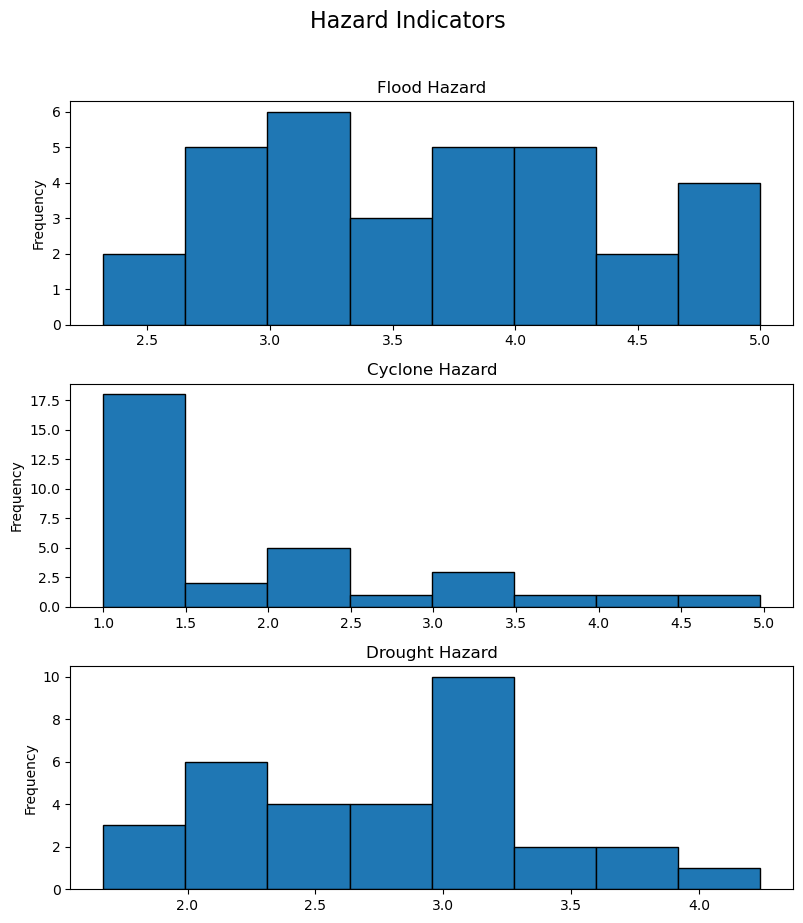

In [19]:
#hazard
plot_histograms(
    master,
    dimensions["Hazard"],
    "Hazard Indicators"
)

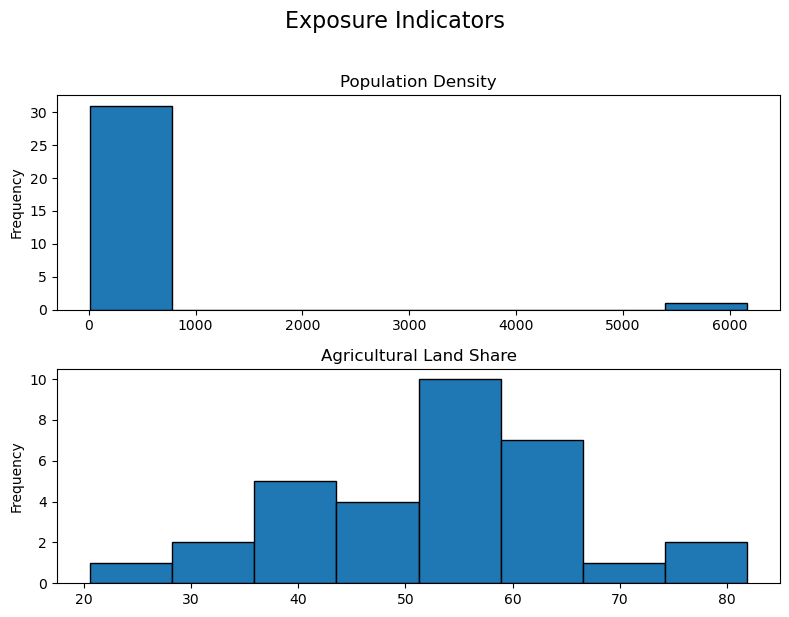

In [20]:
#exposure
plot_histograms(
    master,
    dimensions["Exposure"],
    "Exposure Indicators"
)

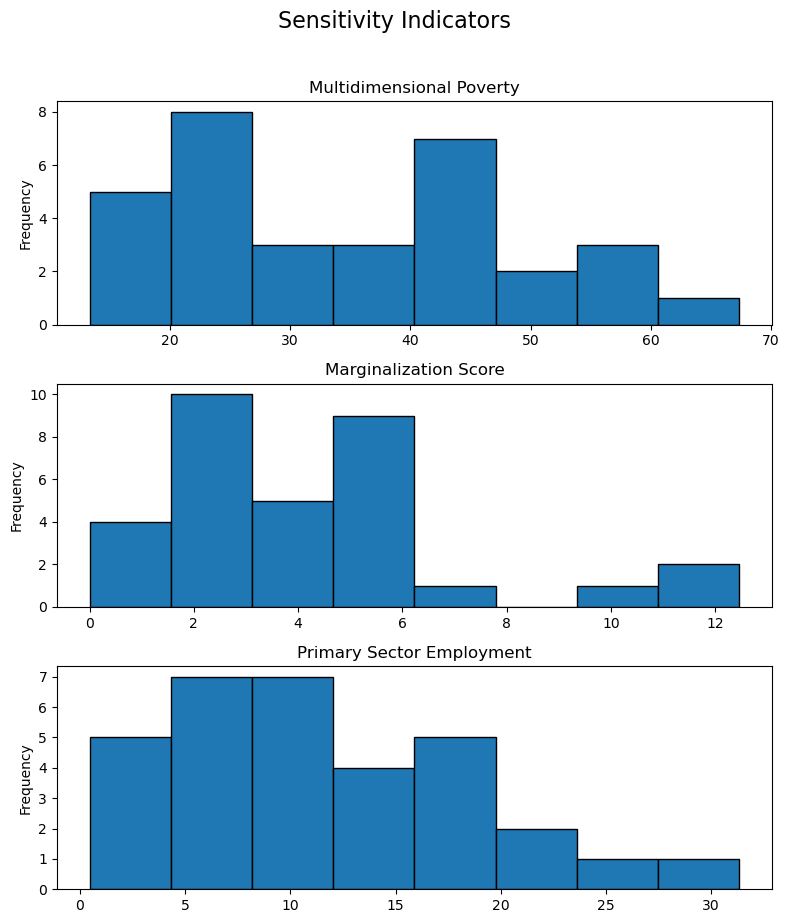

In [21]:
#sensitivity
plot_histograms(
    master,
    dimensions["Sensitivity"],
    "Sensitivity Indicators"
)

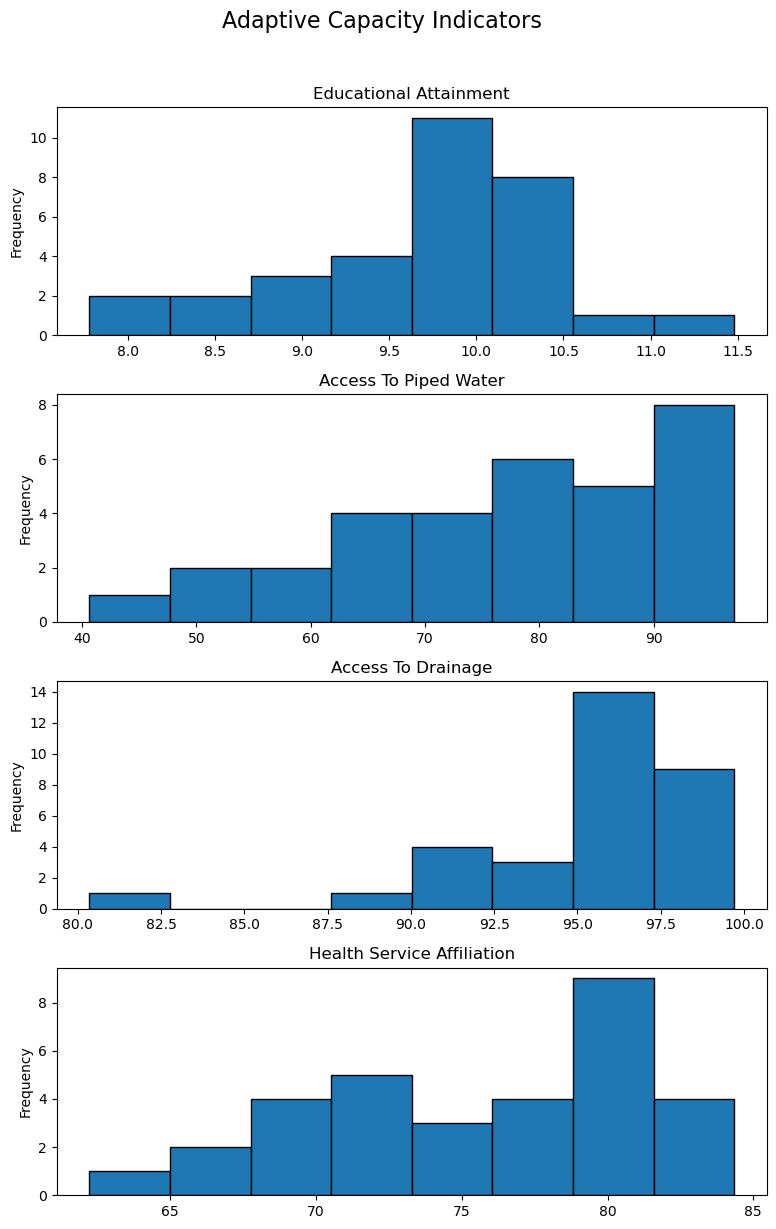

In [22]:
#adaptive capacity
plot_histograms(
    master,
    dimensions["Adaptive Capacity"],
    "Adaptive Capacity Indicators"
)

Interpretation:
- The hazard indicators exhibit distinct distribution patterns across the 32 Mexican states. Flood hazard is relatively evenly distributed, with most states experiencing moderate to high hazard levels. Drought hazard also displays a fairly balanced distribution centered around moderate values, suggesting that water scarcity is a widespread concern throughout the country. In contrast, cyclone hazard is strongly right-skewed, with most states exhibiting very low hazard levels and only a limited number of coastal states experiencing high cyclone exposure. These differences indicate that the selected hazard indicators capture complementary climate threats affecting different regions of Mexico.
- The exposure indicators reveal two contrasting patterns. Population density is extremely right-skewed, reflecting the presence of a single highly urbanized outlier (Ciudad de México) compared with the relatively low population densities observed in most states. Agricultural land share, however, follows a much more balanced distribution, with the majority of states clustering around intermediate values. Together, these indicators capture both urban exposure through the concentration of people and infrastructure, and rural exposure through the extent of productive agricultural land.
- The sensitivity indicators demonstrate considerable socioeconomic variation across Mexico. Multidimensional poverty presents a broad distribution, indicating substantial differences in social vulnerability between states. Primary sector employment is positively skewed, suggesting that while most states have relatively low dependence on climate-sensitive economic activities, a smaller group remains highly reliant on agriculture and related sectors. The marginalization index is more concentrated around intermediate values, although regional disparities remain evident. Overall, these indicators highlight important differences in the socioeconomic conditions that influence states' susceptibility to climate impacts.
- The adaptive capacity indicators generally exhibit more homogeneous distributions than the other dimensions. Educational attainment is approximately symmetric, with most states reporting similar average years of schooling. Health service affiliation and access to piped water show moderate variability, indicating that although coverage is generally high, notable regional inequalities persist. Access to drainage is the most homogeneous indicator, with nearly all states reporting coverage above 90%, suggesting that drainage infrastructure is widely available across the country. Overall, the adaptive capacity indicators indicate relatively strong access to basic services nationwide, while still capturing meaningful differences in education, healthcare, and water infrastructure.

In [23]:
def plot_boxplots(df, variables, title):

    n = len(variables)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(8, 2.5*n)
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):

        ax.boxplot(df[var],
                   vert=False)

        ax.set_title(var.replace("_"," ").title())

    plt.suptitle(title,
                 fontsize=16,
                 y=1.02)

    plt.tight_layout()

    plt.show()

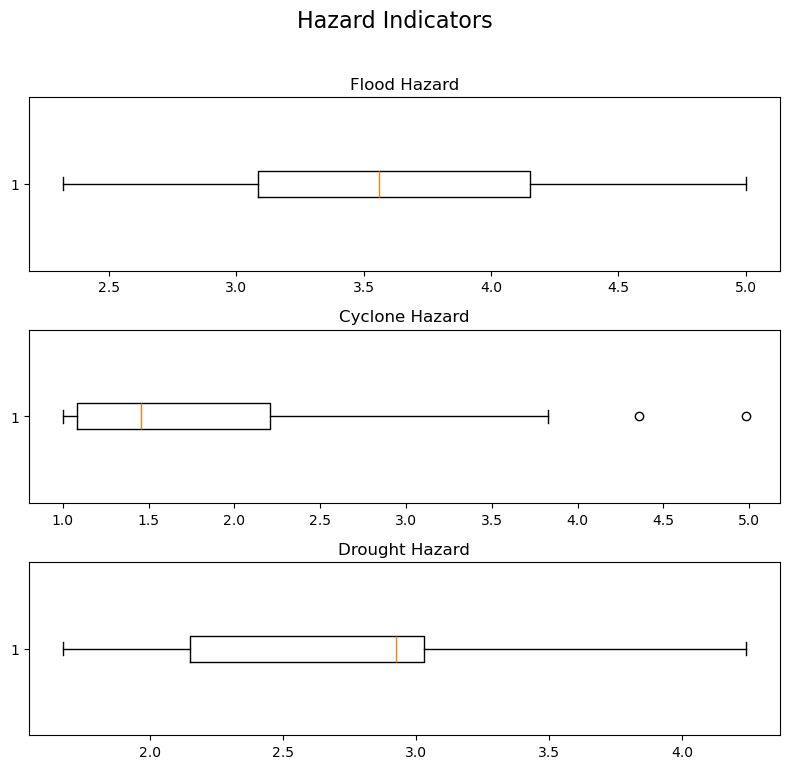

In [24]:
#hazard
plot_boxplots(
    master,
    dimensions["Hazard"],
    "Hazard Indicators"
)

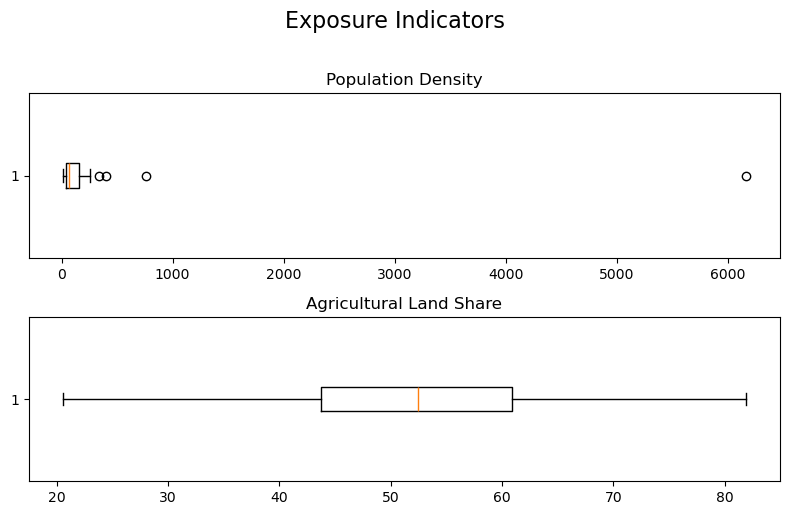

In [25]:
plot_boxplots(
    master,
    dimensions["Exposure"],
    "Exposure Indicators"
)

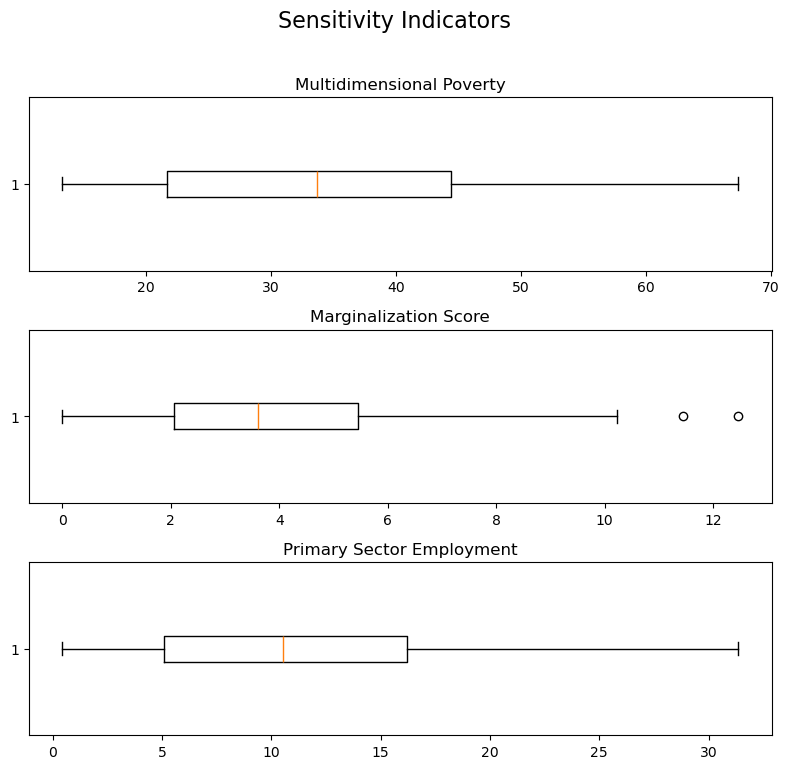

In [26]:
plot_boxplots(
    master,
    dimensions["Sensitivity"],
    "Sensitivity Indicators"
)

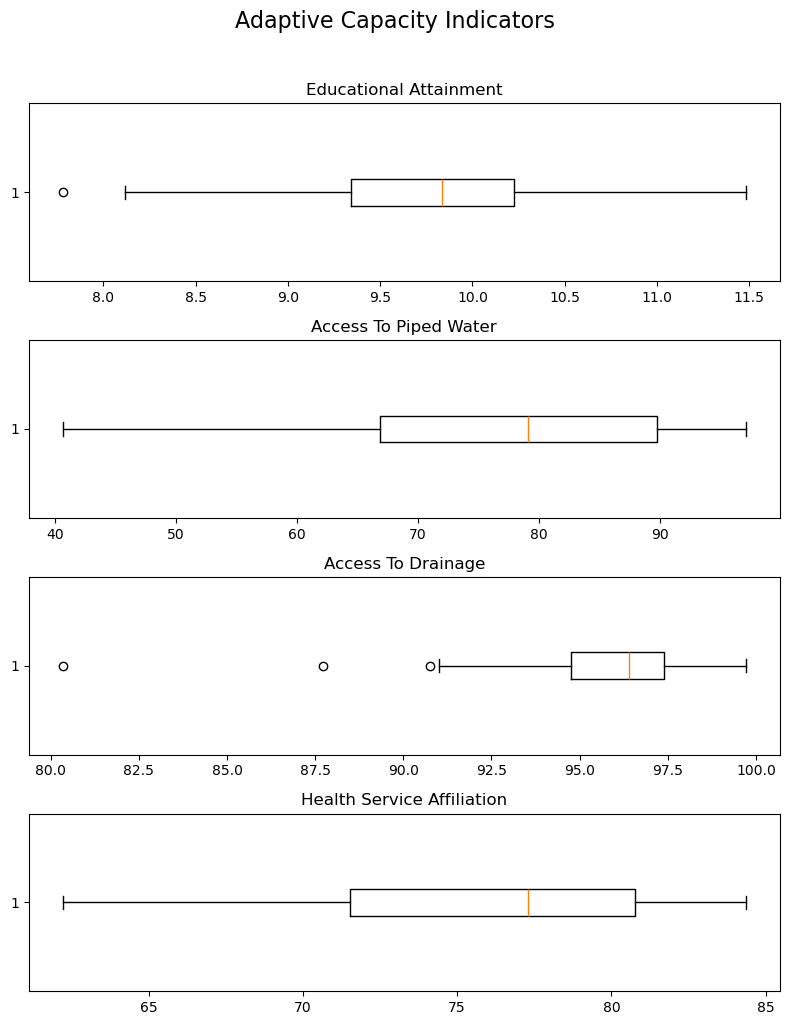

In [27]:
plot_boxplots(
    master,
    dimensions["Adaptive Capacity"],
    "Adaptive Capacity Indicators"
)

In [28]:
#detecting outliers
def detect_outliers(df, variable):

    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[variable] < lower) |
        (df[variable] > upper)
    ]

    return outliers[
        ["state_name", variable]
    ]

In [29]:
for var in indicator_cols:

    print(f"\n{var}")

    display(
        detect_outliers(master, var)
    )


access_to_drainage


,state_name,access_to_drainage
11,Guerrero,87.73
19,Oaxaca,80.34
23,San Luis Potosí,90.76



access_to_piped_water


,state_name,access_to_piped_water



agricultural_land_share


...

,state_name,multidimensional_poverty



population_density


,state_name,population_density
8,Ciudad de México,6163.30
14,México,760.20
16,Morelos,404.10
28,Tlaxcala,336.00



primary_sector_employment


,state_name,primary_sector_employment


In [30]:
#examining skewness
skewness = (
    master[indicator_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness.to_frame("skewness")

,skewness
population_density,5.49
cyclone_hazard,1.41
marginalization_score,1.26
primary_sector_employment,0.80
multidimensional_poverty,0.42
flood_hazard,0.20
drought_hazard,0.19
agricultural_land_share,-0.03
health_service_affiliation,-0.44
educational_attainment,-0.58


### 4. Rankings
This section identifies the states with the highest and lowest values for each indicator.

Ranking states provides a straightforward way to identify regional patterns, highlight the most vulnerable and resilient territories, and better understand the spatial distribution of climate-related risks and adaptive capacities across Mexico.

The results also facilitate the interpretation of later analyses, including outlier detection, correlation analysis, and the construction of the composite Climate Resilience Investment Priority Index.

In [31]:
def plot_ranking(df, indicator, ascending=False):

    ranking = (
        df[
            ["state_name", indicator]
        ]
        .sort_values(
            by=indicator,
            ascending=ascending
        )
        .head(5)
    )

    plt.figure(figsize=(7,4.5))

    plt.barh(
        ranking["state_name"],
        ranking[indicator]
    )

    plt.gca().invert_yaxis()

    title = "Lowest" if ascending else "Highest"

    plt.title(
        f"{title} 5 States - {indicator.replace('_',' ').title()}"
    )

    plt.xlabel("")
    plt.ylabel("")

    plt.tight_layout()

    plt.show()

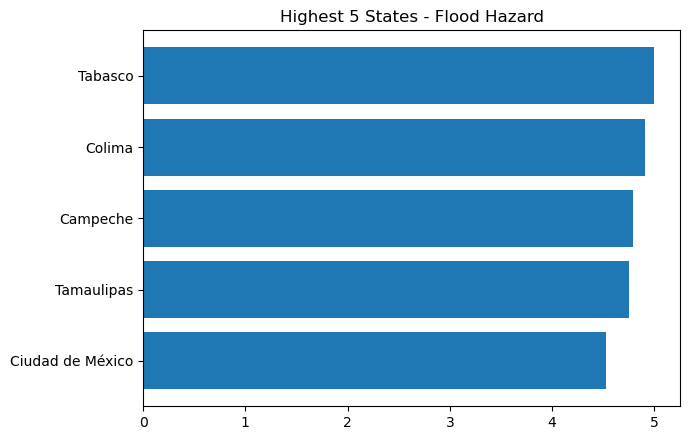

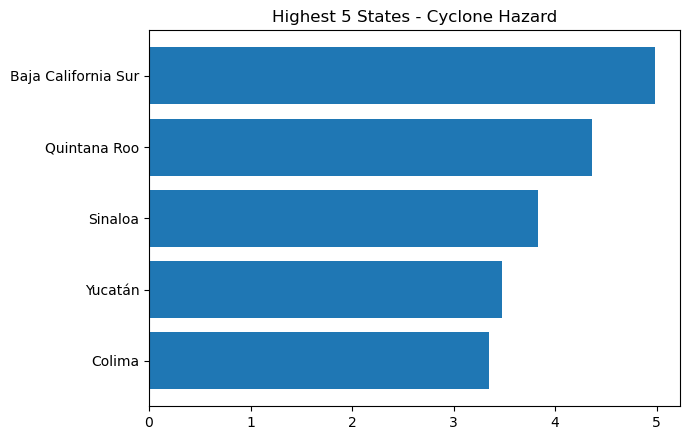

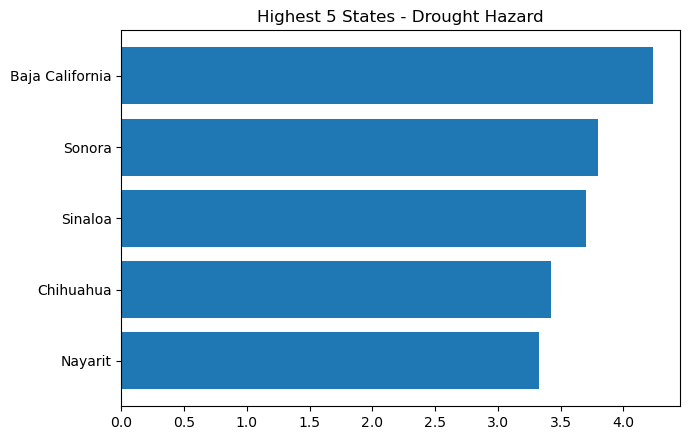

In [32]:
#hazard
for indicator in dimensions["Hazard"]:
    plot_ranking(master, indicator)

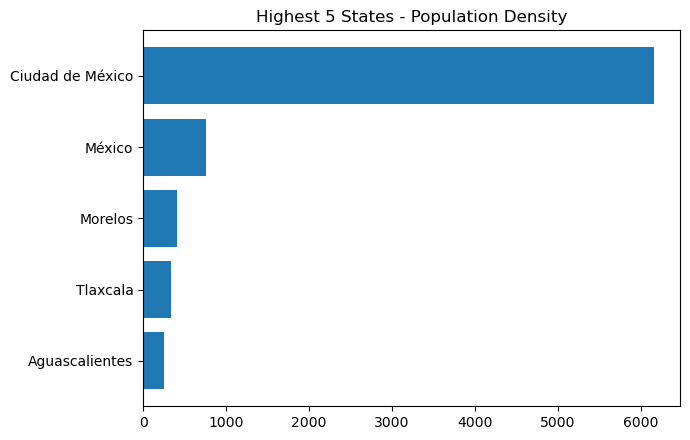

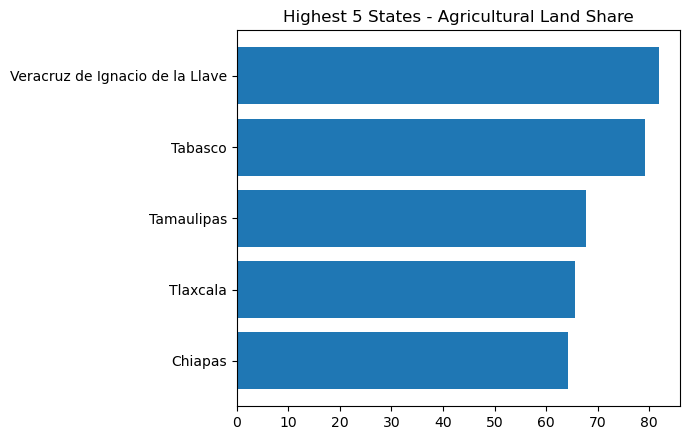

In [33]:
#exposure
for indicator in dimensions["Exposure"]:
    plot_ranking(master, indicator)

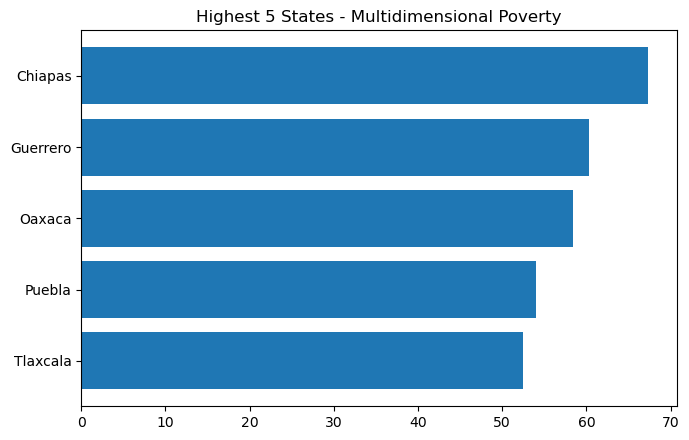

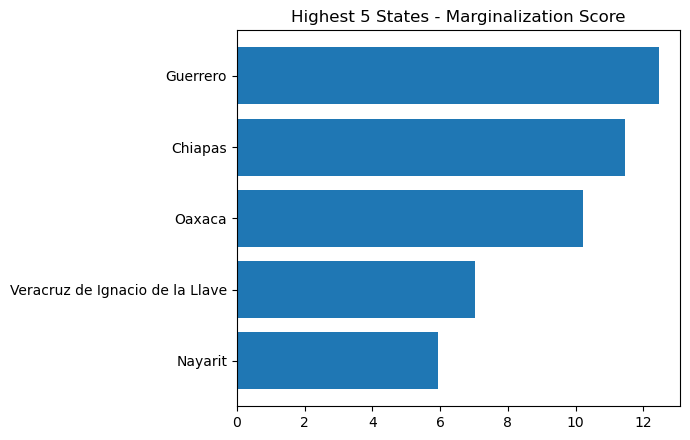

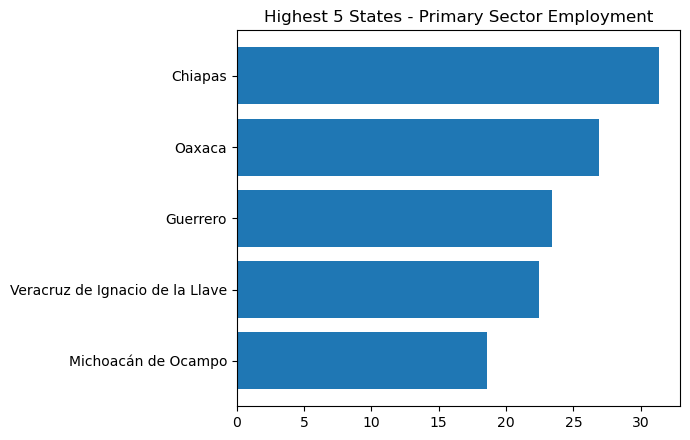

In [34]:
#sensitivity
for indicator in dimensions["Sensitivity"]:
    plot_ranking(master, indicator)

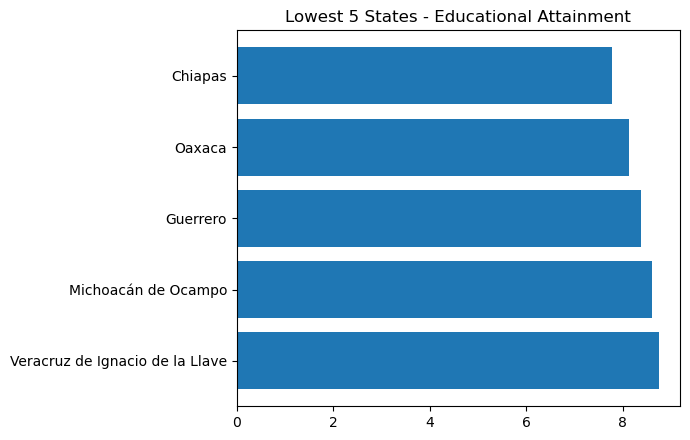

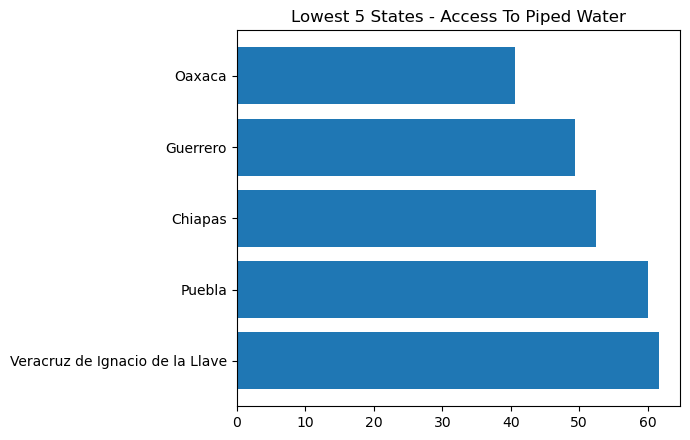

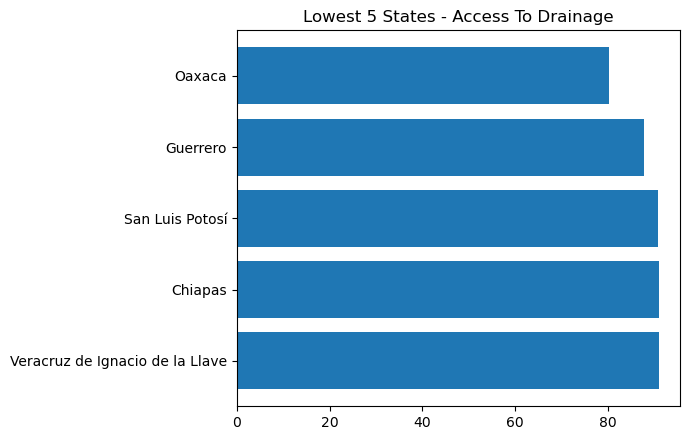

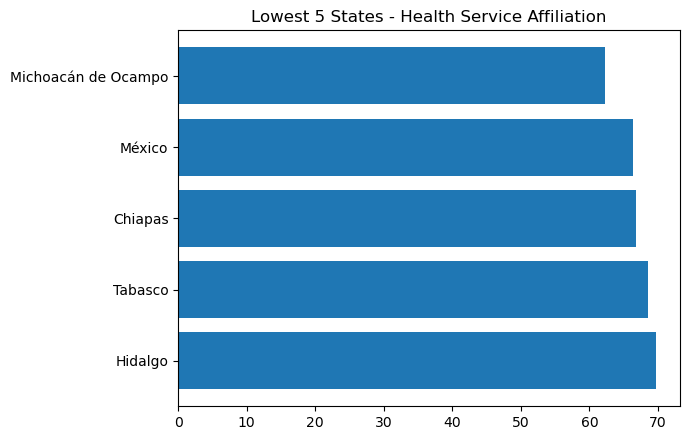

In [35]:
#adaptive capacity
for indicator in dimensions["Adaptive Capacity"]:
    plot_ranking(master, indicator, ascending=True)

Hazard Rankings:

- **Flood hazard** is highest in **Tabasco, Colima, Campeche, Tamaulipas and Ciudad de México**, highlighting states with greater exposure to intense precipitation, flooding events and hydrometeorological impacts.

- **Cyclone hazard** is concentrated almost exclusively in coastal states. **Baja California Sur, Quintana Roo, Sinaloa, Yucatán and Colima** present the highest cyclone hazard, reflecting their exposure to tropical cyclones originating in both the Pacific Ocean and the Atlantic basin.

- **Drought hazard** is dominated by northern and northwestern states, with **Baja California, Sonora, Sinaloa, Chihuahua and Nayarit** showing the highest values. This pattern is consistent with the greater prevalence of arid and semi-arid climates in northern Mexico.

Exposure Rankings:

- **Population density** is overwhelmingly dominated by **Ciudad de México**, which far exceeds every other state in terms of population concentration. The State of México, Morelos, Tlaxcala and Aguascalientes also rank among the most densely populated states, although at substantially lower levels than Mexico City.

- **Agricultural land share** is highest in **Veracruz, Tabasco, Tamaulipas, Tlaxcala and Chiapas**, indicating a greater concentration of productive land potentially exposed to climate-related hazards such as floods, droughts and tropical storms.

Sensitivity Rankins:

- **Multidimensional poverty** is highest in **Chiapas, Guerrero, Oaxaca, Puebla and Tlaxcala**, reflecting substantial social and economic deprivation.

- **Marginalization score** identifies **Guerrero, Chiapas, Oaxaca, Veracruz and Nayarit** as the states with the greatest structural marginalization after reversing the original CONAPO indicator for consistent interpretation.

- **Primary sector employment** is highest in **Chiapas, Oaxaca, Guerrero, Veracruz and Michoacán**, indicating a stronger dependence on climate-sensitive economic activities such as agriculture, forestry and fisheries.

Adpative Capacity Rankings:

- **Educational attainment** is lowest in **Chiapas, Oaxaca, Guerrero, Michoacán and Veracruz**, suggesting lower levels of human capital that may limit adaptive capacity.

- **Access to piped water** is lowest in **Oaxaca, Guerrero, Chiapas, Puebla and Veracruz**, indicating persistent inequalities in access to essential water infrastructure.

- **Access to drainage** is lowest in **Oaxaca, Guerrero, San Luis Potosí, Chiapas and Veracruz**, reflecting deficiencies in sanitation infrastructure that may increase vulnerability to climate-related events.

- **Health service affiliation** is lowest in **Michoacán, Estado de México, Chiapas, Tabasco and Hidalgo**, suggesting comparatively weaker access to healthcare services that support disaster preparedness and recovery.

### 5. Correlation Analysis
Objectives:
1. Identify relationships between indicators.
2. Detect possible multicollinearity.
3. Validate that our indicator selection is appropriate.
4. Generate meaningful insights.
5. Help justify the weighting/index construction later.

In [36]:
#correlation matrix
corr = master.drop(columns=["state_code", "state_name"]).corr(method="pearson")

corr.round(2)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,multidimensional_poverty,primary_sector_employment,educational_attainment,access_to_piped_water,access_to_drainage,health_service_affiliation,population_density,agricultural_land_share,flood_hazard,cyclone_hazard,drought_hazard,marginalization_score
multidimensional_poverty,1.00,0.81,-0.82,-0.91,-0.63,-0.64,-0.10,0.36,-0.07,-0.25,-0.55,0.84
primary_sector_employment,0.81,1.00,-0.90,-0.83,-0.72,-0.42,-0.29,0.27,-0.08,-0.07,-0.38,0.89
educational_attainment,-0.82,-0.90,1.00,0.80,0.73,0.48,0.42,-0.27,0.12,0.14,0.38,-0.90
access_to_piped_water,-0.91,-0.83,0.80,1.00,0.77,0.53,0.15,-0.17,0.07,0.11,0.53,-0.89
access_to_drainage,-0.63,-0.72,0.73,0.77,1.00,0.21,0.24,0.04,0.13,-0.02,0.31,-0.82
health_service_affiliation,-0.64,-0.42,0.48,0.53,0.21,1.00,-0.15,-0.30,-0.06,0.31,0.23,-0.42
population_density,-0.10,-0.29,0.42,0.15,0.24,-0.15,1.00,-0.16,0.22,-0.20,0.04,-0.26
agricultural_land_share,0.36,0.27,-0.27,-0.17,0.04,-0.30,-0.16,1.00,0.37,-0.33,-0.08,0.19
flood_hazard,-0.07,-0.08,0.12,0.07,0.13,-0.06,0.22,0.37,1.00,0.13,0.19,-0.09
cyclone_hazard,-0.25,-0.07,0.14,0.11,-0.02,0.31,-0.20,-0.33,0.13,1.00,0.28,-0.03


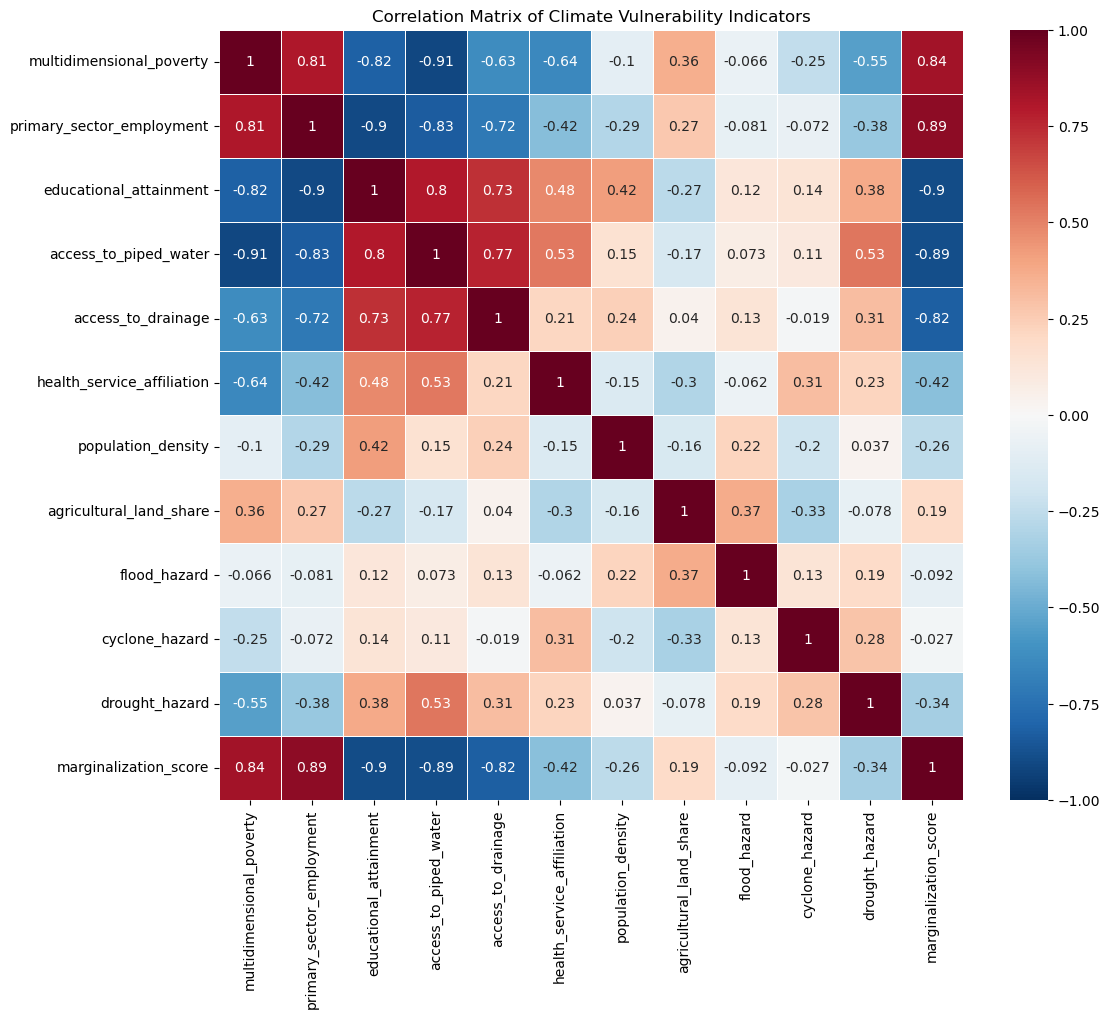

In [37]:
#heatpmap
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=.5
)

plt.title("Correlation Matrix of Climate Vulnerability Indicators")
plt.show()

In [38]:
corr_pairs = (
    corr
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Indicator_1",
    "Indicator_2",
    "Correlation"
]

corr_pairs["Absolute"] = corr_pairs["Correlation"].abs()

corr_pairs = corr_pairs.sort_values(
    "Absolute",
    ascending=False
)

corr_pairs.head(15)

,Indicator_1,Indicator_2,Correlation,Absolute
2,multidimensional_poverty,access_to_piped_water,-0.91,0.91
11,primary_sector_employment,educational_attainment,-0.90,0.90
29,educational_attainment,marginalization_score,-0.90,0.90
20,primary_sector_employment,marginalization_score,0.89,0.89
37,access_to_piped_water,marginalization_score,-0.89,0.89
10,multidimensional_poverty,marginalization_score,0.84,0.84
12,primary_sector_employment,access_to_piped_water,-0.83,0.83
44,access_to_drainage,marginalization_score,-0.82,0.82
1,multidimensional_poverty,educational_attainment,-0.82,0.82
0,multidimensional_poverty,primary_sector_employment,0.81,0.81


In [39]:
hazard = master[
    [
        "flood_hazard",
        "cyclone_hazard",
        "drought_hazard"
    ]
]

hazard.corr().round(2)

,flood_hazard,cyclone_hazard,drought_hazard
flood_hazard,1.00,0.13,0.19
cyclone_hazard,0.13,1.00,0.28
drought_hazard,0.19,0.28,1.00


In [40]:
exposure = master[
    [
        "population_density",
        "agricultural_land_share"
    ]
]

exposure.corr().round(2)

,population_density,agricultural_land_share
population_density,1.00,-0.16
agricultural_land_share,-0.16,1.00


In [41]:
sensitivity = master[
    [
        "multidimensional_poverty",
        "marginalization_score",
        "primary_sector_employment"
    ]
]

sensitivity.corr().round(2)

,multidimensional_poverty,marginalization_score,primary_sector_employment
multidimensional_poverty,1.00,0.84,0.81
marginalization_score,0.84,1.00,0.89
primary_sector_employment,0.81,0.89,1.00


In [42]:
adaptive = master[
    [
        "educational_attainment",
        "access_to_piped_water",
        "access_to_drainage",
        "health_service_affiliation"
    ]
]

adaptive.corr().round(2)

,educational_attainment,access_to_piped_water,access_to_drainage,health_service_affiliation
educational_attainment,1.00,0.80,0.73,0.48
access_to_piped_water,0.80,1.00,0.77,0.53
access_to_drainage,0.73,0.77,1.00,0.21
health_service_affiliation,0.48,0.53,0.21,1.00


Interpretation:
The Pearson correlation analysis reveals several strong relationships among the selected indicators, particularly within the Sensitivity and Adaptive Capacity dimensions. These findings support the conceptual framework developed through the literature review while also demonstrating that the indicators capture complementary aspects of climate vulnerability.

The strongest negative correlation is observed between **multidimensional poverty and access to piped water (r = -0.91)**, indicating that states with higher poverty levels generally have substantially lower access to basic water infrastructure.

Similarly, **primary sector employment and educational attainment exhibit a very strong negative relationship (r = -0.90)**, suggesting that states with greater dependence on agriculture, forestry and fisheries tend to have lower average educational attainment.

The **marginalization score** is strongly associated with multiple indicators. It is negatively correlated with educational attainment (r = -0.90), access to piped water (r = -0.89) and access to drainage (r = -0.82), while showing strong positive relationships with multidimensional poverty (r = 0.84) and primary sector employment (r = 0.89). These patterns indicate that socially marginalized states consistently experience multiple socioeconomic disadvantages.

Adaptive capacity indicators also demonstrate strong internal consistency. Educational attainment is positively associated with access to piped water (r = 0.80) and access to drainage (r = 0.73), while piped water and drainage are themselves strongly correlated (r = 0.77). These relationships suggest that states with better educational outcomes also tend to possess stronger public infrastructure.

Finally, multidimensional poverty shows strong positive correlations with primary sector employment (r = 0.81) and strong negative correlations with educational attainment (r = -0.82), reinforcing the interconnected nature of socioeconomic vulnerability in Mexico.

### 6. Scatterplots

In [53]:
def scatter_plot(df, x, y):

    plt.figure(figsize=(8,6))

    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={"s":70, "alpha":0.8},
        line_kws={"color":"red"}
    )

    plt.xlabel(x.replace("_", " ").title())
    plt.ylabel(y.replace("_", " ").title())
    plt.title(f"{y.replace('_', ' ').title()} vs {x.replace('_', ' ').title()}")

    plt.tight_layout()
    plt.show()

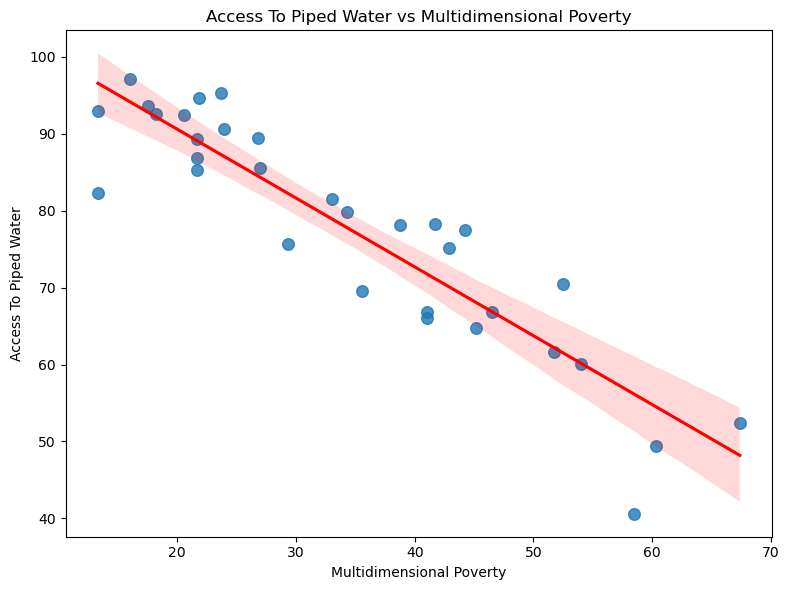

In [54]:
#poverty vs piped water
scatter_plot(
    master,
    "multidimensional_poverty",
    "access_to_piped_water"
)

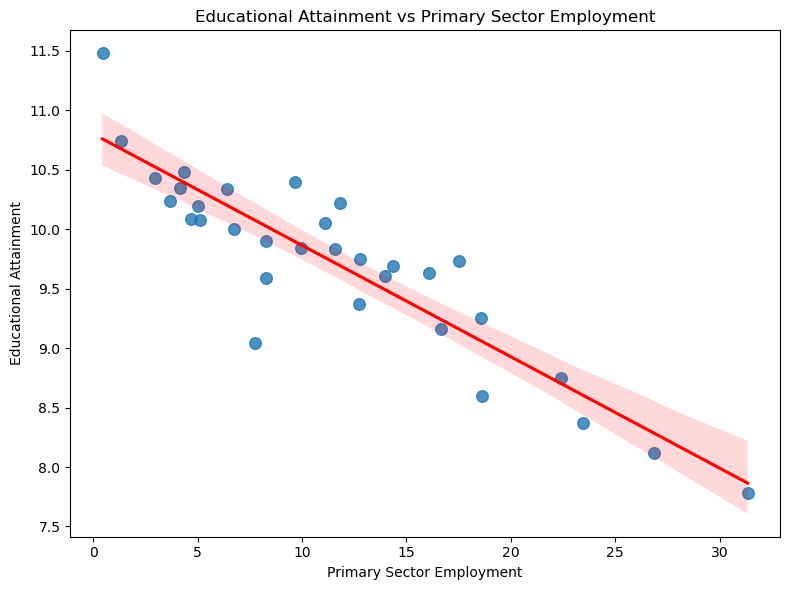

In [55]:
#primary sector employment vs educational attainment
scatter_plot(
    master,
    "primary_sector_employment",
    "educational_attainment"
)

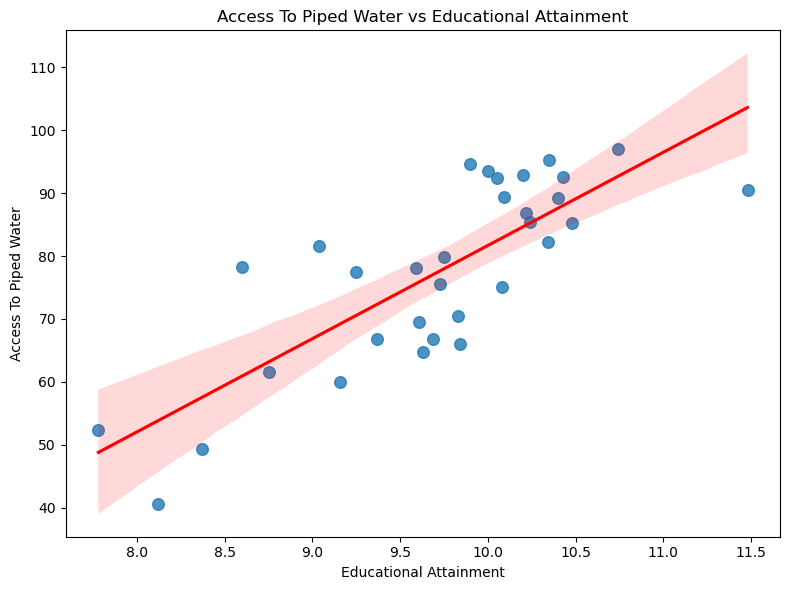

In [56]:
#educational attainment vs piped water
scatter_plot(
    master,
    "educational_attainment",
    "access_to_piped_water"
)

### 7. Dimension Index Construction & Analysis
Objectives:
- Which states have the highest overall hazard?
- Which states have the lowest adaptive capacity?
- Do hazard and adaptive capacity overlap?
- Are the dimensions independent, or are they correlated?
- Which dimension contributes most to overall vulnerability?

These analyses will directly support the construction of your composite index.

In [57]:
#normalizing the indicators to the same range with Min-Max normalization
indicator_columns = [
    "flood_hazard",
    "cyclone_hazard",
    "drought_hazard",
    "population_density",
    "agricultural_land_share",
    "multidimensional_poverty",
    "marginalization_score",
    "primary_sector_employment",
    "educational_attainment",
    "access_to_piped_water",
    "access_to_drainage",
    "health_service_affiliation"
]

In [58]:
from sklearn.preprocessing import MinMaxScaler

In [59]:
scaler = MinMaxScaler()

master_norm = master.copy()

master_norm[indicator_columns] = scaler.fit_transform(
    master[indicator_columns]
)

In [60]:
master_norm[indicator_columns].describe().loc[["min", "max"]]

,flood_hazard,cyclone_hazard,drought_hazard,population_density,agricultural_land_share,multidimensional_poverty,marginalization_score,primary_sector_employment,educational_attainment,access_to_piped_water,access_to_drainage,health_service_affiliation
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [61]:
#reversing adaptive capacity indicators to keep interpretation consistent
adaptive_capacity = [
    "educational_attainment",
    "access_to_piped_water",
    "access_to_drainage",
    "health_service_affiliation"
]

master_norm[adaptive_capacity] = (
    1 - master_norm[adaptive_capacity]
)

In [62]:
#hazard
master_norm["hazard_score"] = master_norm[
    [
        "flood_hazard",
        "cyclone_hazard",
        "drought_hazard"
    ]
].mean(axis=1)

In [63]:
#exposure
master_norm["exposure_score"] = master_norm[
    [
        "population_density",
        "agricultural_land_share"
    ]
].mean(axis=1)

In [64]:
#sensitivity
master_norm["sensitivity_score"] = master_norm[
    [
        "multidimensional_poverty",
        "marginalization_score",
        "primary_sector_employment"
    ]
].mean(axis=1)

In [65]:
#adaptive capacity
master_norm["adaptive_capacity_score"] = master_norm[
    adaptive_capacity
].mean(axis=1)

In [66]:
master_norm.head()

,state_code,state_name,multidimensional_poverty,primary_sector_employment,educational_attainment,access_to_piped_water,access_to_drainage,health_service_affiliation,population_density,agricultural_land_share,flood_hazard,cyclone_hazard,drought_hazard,marginalization_score,hazard_score,exposure_score,sensitivity_score,adaptive_capacity_score
0,01,Aguascalientes,0.19,0.12,0.31,0.03,0.02,0.13,0.04,0.58,0.18,0.00,0.13,0.10,0.10,0.31,0.14,0.12
1,02,Baja California,0.00,0.15,0.35,0.07,0.18,0.33,0.01,0.21,0.38,0.12,1.00,0.17,0.50,0.11,0.10,0.23
2,03,Baja California Sur,0.00,0.19,0.31,0.26,0.15,0.05,0.00,0.00,0.00,1.00,0.51,0.16,0.50,0.00,0.12,0.19
3,04,Campeche,0.59,0.51,0.50,0.57,0.27,0.31,0.00,0.57,0.92,0.53,0.52,0.45,0.66,0.29,0.52,0.41
4,05,Coahuila de Zaragoza,0.09,0.08,0.28,0.08,0.06,0.16,0.00,0.39,0.23,0.05,0.50,0.07,0.26,0.19,0.08,0.15


In [67]:
master_norm[
    [
        "hazard_score",
        "exposure_score",
        "sensitivity_score",
        "adaptive_capacity_score"
    ]
].describe()

,hazard_score,exposure_score,sensitivity_score,adaptive_capacity_score
count,32.00,32.00,32.00,32.00
mean,0.38,0.29,0.36,0.36
std,0.18,0.13,0.24,0.19
min,0.07,0.00,0.03,0.10
25%,0.24,0.20,0.18,0.20
50%,0.39,0.27,0.34,0.33
75%,0.50,0.36,0.49,0.44
max,0.74,0.65,0.97,0.89


In [68]:
master_norm = master_norm.rename(columns={
    "hazard_score": "hazard_dimension_index",
    "exposure_score": "exposure_dimension_index",
    "sensitivity_score": "sensitivity_dimension_index",
    "adaptive_capacity_score": "adaptive_capacity_dimension_index"
})

In [71]:
#csv file with normalized indicators
master_norm.to_csv(
    "../data/processed/climate_resilience_master_norm.csv",
    index=False
)

In [72]:
#csv file for Tableau
dashboard = master.copy()

dashboard["hazard_dimension_index"] = master_norm["hazard_dimension_index"]
dashboard["exposure_dimension_index"] = master_norm["exposure_dimension_index"]
dashboard["sensitivity_dimension_index"] = master_norm["sensitivity_dimension_index"]
dashboard["adaptive_capacity_dimension_index"] = master_norm["adaptive_capacity_dimension_index"]

In [73]:
def plot_dimension_ranking(df, column):

    ranking = (
        df[["state_name", column]]
        .sort_values(by=column, ascending=False)
        .head(5)
    )

    plt.figure(figsize=(7,4.5))

    plt.barh(
        ranking["state_name"],
        ranking[column]
    )

    plt.gca().invert_yaxis()

    plt.title(
        f"Top 5 States - {column.replace('_', ' ').title()}"
    )

    plt.xlabel("Dimension Index")
    plt.ylabel("")

    plt.tight_layout()

    plt.show()

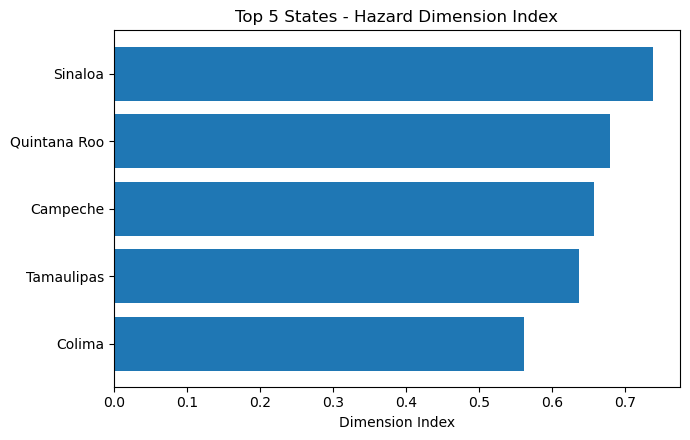

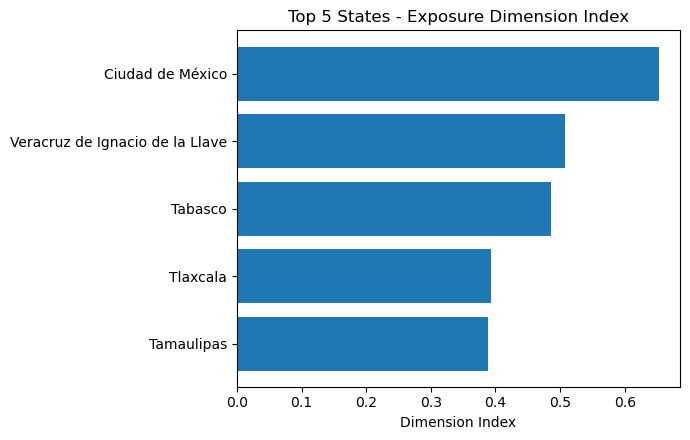

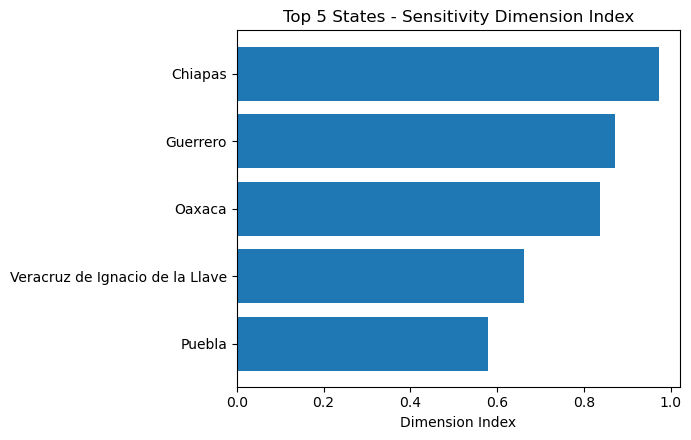

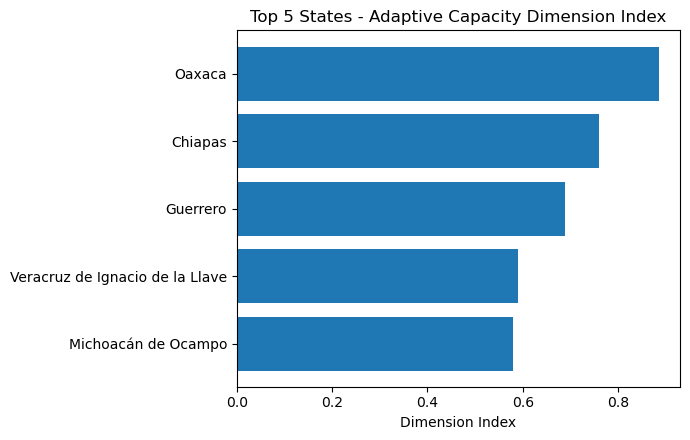

In [74]:
dimension_indices = [
    "hazard_dimension_index",
    "exposure_dimension_index",
    "sensitivity_dimension_index",
    "adaptive_capacity_dimension_index"
]

for dimension in dimension_indices:
    plot_dimension_ranking(master_norm, dimension)

Interpretation:
- The highest **hazard** scores are observed in Sinaloa, Quintana Roo, Campeche, Tamaulipas, and Colima.
These states consistently face multiple climate-related hazards rather than a single isolated risk. Their high scores result from the combined influence of floods, cyclones, and droughts, highlighting regions where climatic threats are particularly pronounced. Coastal states dominate the ranking, reflecting their exposure to tropical cyclones and flooding, while northwestern states such as Sinaloa are additionally characterized by elevated drought susceptibility.

- The highest **exposure** is found in Ciudad de México, Veracruz, Tabasco, Tlaxcala, and Tamaulipas.
Exposure reflects the concentration of people and productive agricultural land that could potentially be affected by climate hazards. Ciudad de México clearly stands out due to its exceptionally high population density, while Veracruz and Tabasco combine extensive agricultural land with relatively large populations, increasing the number of people and assets exposed to climate-related events.

- The highest **exposure** is found in Ciudad de México, Veracruz, Tabasco, Tlaxcala, and Tamaulipas.
Exposure reflects the concentration of people and productive agricultural land that could potentially be affected by climate hazards. Ciudad de México clearly stands out due to its exceptionally high population density, while Veracruz and Tabasco combine extensive agricultural land with relatively large populations, increasing the number of people and assets exposed to climate-related events.

- The highest **adaptive vulnerability** is observed in Oaxaca, Chiapas, Guerrero, Veracruz, and Michoacán.
Since the adaptive capacity indicators were reversed during normalization, higher values indicate lower adaptive capacity. These states exhibit comparatively lower educational attainment and more limited access to basic infrastructure and health services, suggesting a reduced ability to prepare for, respond to, and recover from climate-related shocks.

Climate vulnerability in Mexico is multidimensional. States with the highest climate hazards are not necessarily the same states with the highest socioeconomic vulnerability or the lowest adaptive capacity. This reinforces the need for a composite framework that integrates all four dimensions rather than relying on a single indicator.

In [75]:
#correlation matrix for the four dimensions
dimension_indices = [
    "hazard_dimension_index",
    "exposure_dimension_index",
    "sensitivity_dimension_index",
    "adaptive_capacity_dimension_index"
]

dimension_corr = (
    master_norm[dimension_indices]
    .corr()
)

dimension_corr.round(2)

,hazard_dimension_index,exposure_dimension_index,sensitivity_dimension_index,adaptive_capacity_dimension_index
hazard_dimension_index,1.00,0.01,-0.31,-0.32
exposure_dimension_index,0.01,1.00,0.09,0.06
sensitivity_dimension_index,-0.31,0.09,1.00,0.94
adaptive_capacity_dimension_index,-0.32,0.06,0.94,1.00


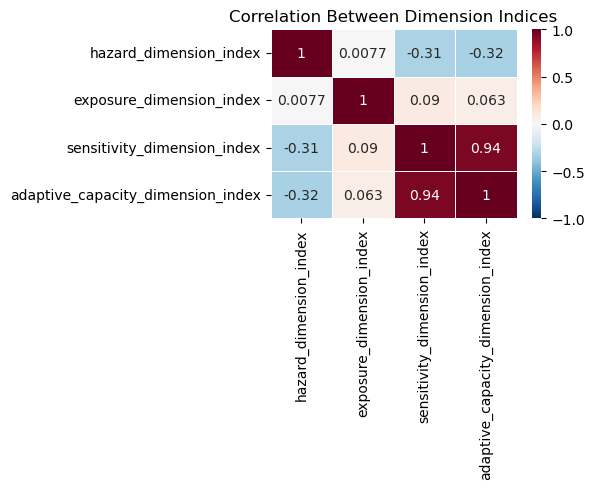

In [76]:
#heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    dimension_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=.5
)

plt.title("Correlation Between Dimension Indices")

plt.tight_layout()

plt.show()

Interpretation:

The correlation matrix reveals that the four dimensions capture distinct but complementary aspects of climate vulnerability, supporting the decision to build a multidimensional framework rather than relying on a single indicator.

The strongest relationship is observed between the Sensitivity Dimension Index and the Adaptive Capacity Dimension Index (r = 0.94). This indicates that states characterized by higher socioeconomic vulnerability also tend to exhibit lower adaptive capacity. In practice, states with higher poverty, greater marginalization, and stronger dependence on the primary sector generally also have lower educational attainment and reduced access to basic infrastructure and health services.

The Hazard Dimension Index shows a weak negative correlation with both Sensitivity (r = -0.31) and Adaptive Capacity (r = -0.32). This suggests that states experiencing the greatest climate hazards are not necessarily those with the highest socioeconomic vulnerability. Climate hazards are primarily determined by geographic and climatic conditions, whereas sensitivity and adaptive capacity reflect social and economic characteristics.

Finally, the Exposure Dimension Index exhibits almost no correlation with the other three dimensions (correlations ranging from 0.01 to 0.09). This indicates that population density and agricultural land distribution represent an independent component of climate vulnerability and contribute unique information to the framework.

In [77]:
#state x dimension heatmap
dimension_matrix = (
    master_norm[
        [
            "state_name",
            "hazard_dimension_index",
            "exposure_dimension_index",
            "sensitivity_dimension_index",
            "adaptive_capacity_dimension_index"
        ]
    ]
    .set_index("state_name")
)

In [78]:
dimension_matrix = dimension_matrix.sort_values(
    by="sensitivity_dimension_index",
    ascending=False
)

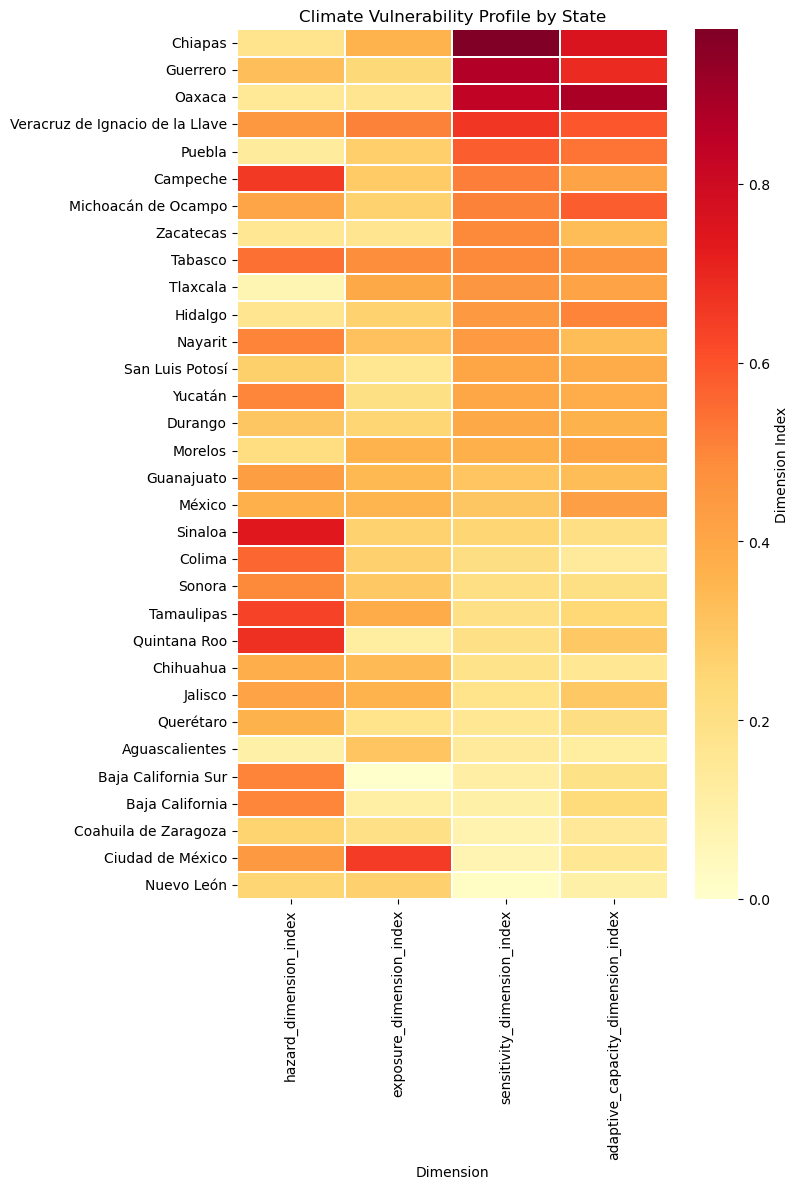

In [79]:
plt.figure(figsize=(8,12))

sns.heatmap(
    dimension_matrix,
    cmap="YlOrRd",
    linewidths=.3,
    cbar_kws={"label": "Dimension Index"}
)

plt.title("Climate Vulnerability Profile by State")

plt.xlabel("Dimension")

plt.ylabel("")

plt.tight_layout()

plt.show()

In [80]:
from scipy.cluster.hierarchy import linkage

<Figure size 1000x1000 with 0 Axes>

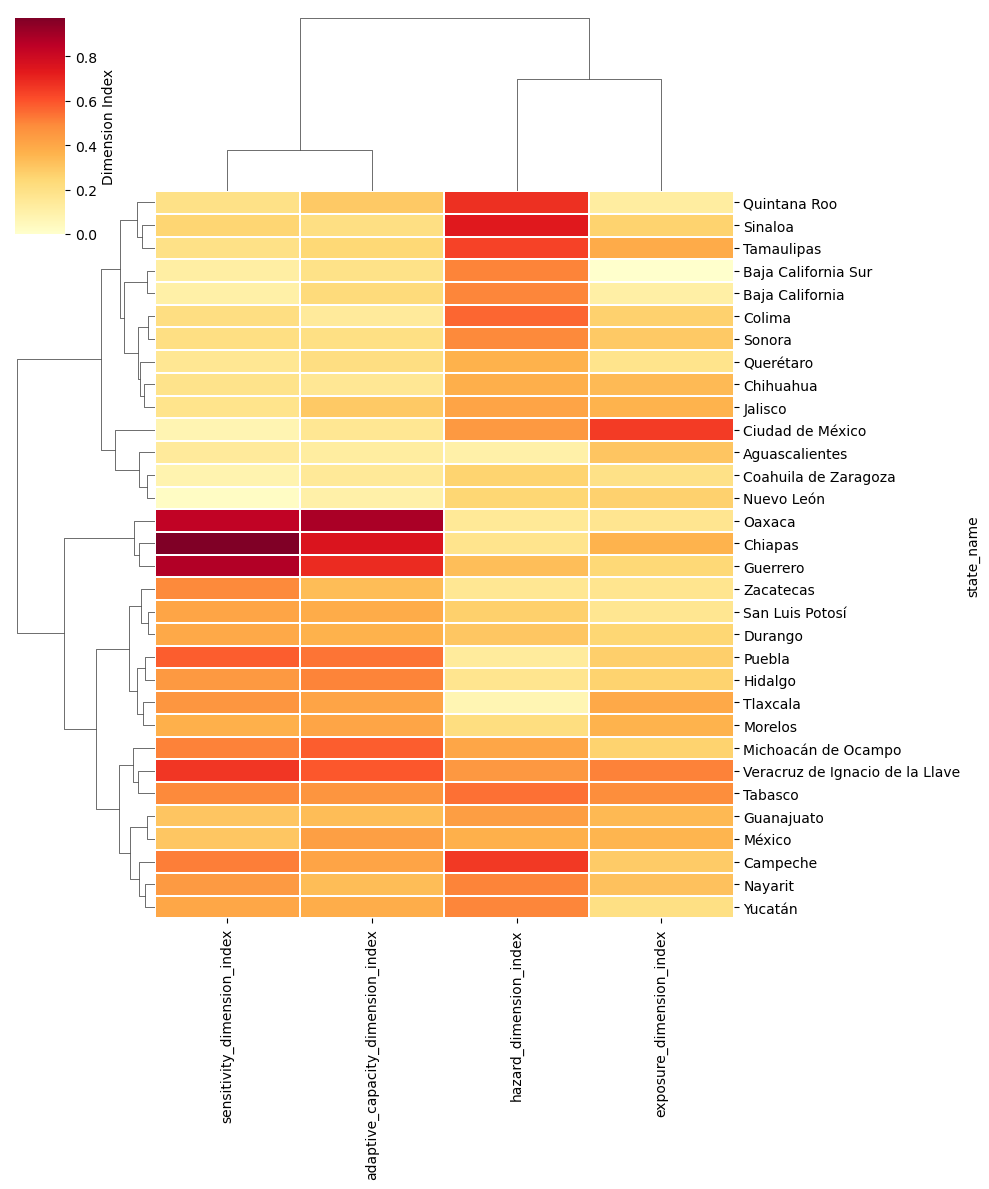

In [81]:
# creating a cluster map
plt.figure(figsize=(10,10))

sns.clustermap(
    dimension_matrix,
    cmap="YlOrRd",
    method="ward",
    metric="euclidean",
    linewidths=.3,
    figsize=(10,12),
    cbar_kws={"label":"Dimension Index"}
)

plt.show()